# Module 1 Exercises — What Is an Agent, Really? (LangGraph)

Work through these in order. Exercises 0 and 1 are pre-work for Session B. Exercise 2 is the build lab and homework.

> **The course rule:** no `ToolNode`, no `tools_condition`, no `create_agent` this week. You hand-write every node. The prebuilts arrive in Module 2, after you can explain what they do.

Run this first — every model cell below needs your key:

In [ ]:
import os
assert os.environ.get("ANTHROPIC_API_KEY"), "Set ANTHROPIC_API_KEY first"
print("key found")

## Exercise 0 — Setup and hello world (15 min)

1. Confirm `pip install -U langgraph "langchain[anthropic]"` succeeded and your key is exported.
2. Run the hello-world call below.
3. Read the printed cost of that single call (Opus 4.8: $5/M input, $25/M output).

In [1]:
from langchain.chat_models import init_chat_model

INPUT_USD_PER_MTOK, OUTPUT_USD_PER_MTOK = 5.0, 25.0

def cost_of(usage):
    return (usage["input_tokens"] / 1_000_000 * INPUT_USD_PER_MTOK
            + usage["output_tokens"] / 1_000_000 * OUTPUT_USD_PER_MTOK)

model = init_chat_model("mistral",
    model_provider="ollama",
    temperature=0,)
response = model.invoke("Explain what a token is, in two sentences.")

print(response.content)
u = response.usage_metadata
print(f"\nInput tokens:  {u['input_tokens']}")
print(f"Output tokens: {u['output_tokens']}")
print(f"Cost of this call: ${cost_of(u):.6f}")

 A token, in the context of technology and cryptocurrency, refers to a digital representation of value or access that is recorded in a blockchain database. It can be used for various purposes such as trading, authentication, or accessing certain services or platforms.

Input tokens:  15
Output tokens: 53
Cost of this call: $0.001400


**Check yourself.** Your one call probably cost a fraction of a cent. Now estimate an agent that loops 40 times with a growing history averaging 20K input tokens per call. Run it — and note that the *input* side dominates, because the whole history is resent every loop. We revisit this in Module 4.

In [2]:
loops, avg_input, avg_output = 40, 20_000, 400
est = loops * cost_of({"input_tokens": avg_input, "output_tokens": avg_output})
print(f"Estimated cost of a 40-loop agent (~20K input tokens/call): ${est:.4f}")

Estimated cost of a 40-loop agent (~20K input tokens/call): $4.4000


## Exercise 1 — Statelessness (25 min)

### Part A — by hand

Reproduce the Priya example: two `model.invoke` calls, history carried in **your own list**. Then break it: delete the first two messages and confirm the model has forgotten the name.

In [3]:
from langchain_core.messages import HumanMessage

messages = [HumanMessage("My name is Dyuti.")]
messages.append(model.invoke(messages))
messages.append(HumanMessage("What is my name?"))
print("WITH history: ", model.invoke(messages).content)

# Now break it — drop the first two messages, ask again:
broken = messages[2:]
print("WITHOUT history:", model.invoke(broken).content)

WITH history:   Your name, as per the introduction, is Dyuti. Is there anything specific you would like help with or information about?
WITHOUT history:  I don't have personal knowledge or access to personal data, so I don't know your name. However, if you want to tell me your name, we can use it in our conversation!


### Part B — with a checkpointer

Build the smallest possible graph and let LangGraph carry the history instead. The checkpointer is just Part A automated: it keeps the message list per `thread_id` and resends it — it does not give the model memory.

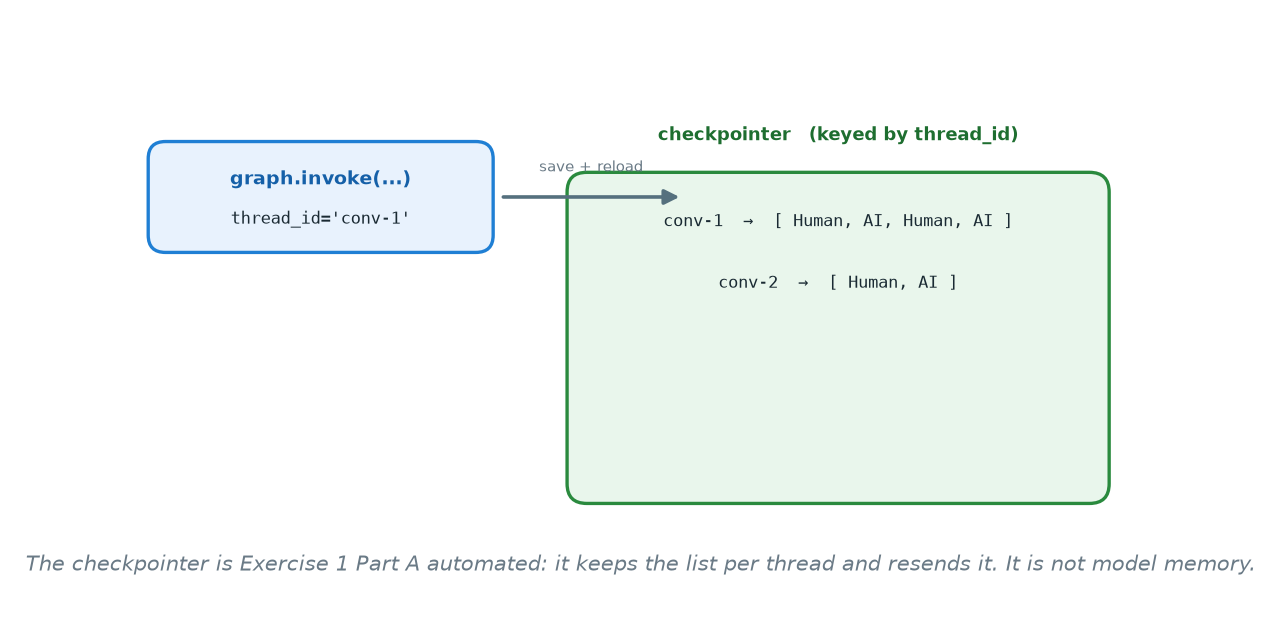

In [4]:
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.checkpoint.memory import InMemorySaver

def agent_node(state: MessagesState):
    return {"messages": [model.invoke(state["messages"])]}

builder = StateGraph(MessagesState)
builder.add_node("agent", agent_node)
builder.add_edge(START, "agent")
builder.add_edge("agent", END)

graph = builder.compile(checkpointer=InMemorySaver())

config = {"configurable": {"thread_id": "conversation-1"}}
graph.invoke({"messages": [("user", "My name is Dyuti.")]}, config)
config = {"configurable": {"thread_id": "conversation-2"}}
result = graph.invoke({"messages": [("user", "What is my name?")]}, config)
print(result["messages"][-1].content)

 I don't have personal knowledge or access to personal data, so I don't know your name. However, if you want to tell me your name, we can use it in our conversation!


Now answer these in the markdown cell below (they are graded):

1. Change `thread_id` to `"conversation-2"` for the second call only. What happens, and why?
2. Given Part A, describe in one sentence what the checkpointer must actually be doing under the hood.
3. Inspect `result["messages"]` — how many messages are in the thread's state after both calls? Where did each come from?

*Your answers (Exercise 1):*

1. 
2. 
3. 

## Exercise 2 — The hand-built calculator agent (core exercise)

Build an agent that answers arithmetic word problems using a calculator tool, as an explicit `StateGraph`: your model node, **your** tool-execution node, **your** router. This week we feel exactly what the prebuilts will later do for us.

### The tool and the model

In [6]:
from langchain.chat_models import init_chat_model
from langchain_core.tools import tool

ALLOWED = set("0123456789+-*/(). %")

@tool
def calculator(expression: str) -> str:
    """Evaluate a Python arithmetic expression, e.g. '1234 * 5678 + 91'.
    Use this for ALL arithmetic - never compute math yourself."""
    if not set(expression) <= ALLOWED:
        return "error: expression contains forbidden characters"
    try:
        return str(eval(expression))  # noqa: S307 - deliberately unsafe, discussed in class
    except Exception as e:
        return f"error: {e}"

model = init_chat_model("mistral",model_provider="ollama",
    temperature=0,)
model_with_tools = model.bind_tools([calculator])

Note what `@tool` did: your function name, type hints, and docstring became a **schema the model can see.** The docstring is a prompt. We return errors as strings instead of raising — the model can read "error: division by zero" and recover; a Python traceback in your process helps nobody.

### Reference skeleton

Try writing the graph yourself from section 5 of the guide before reading this. Then compare. The shape you are building:

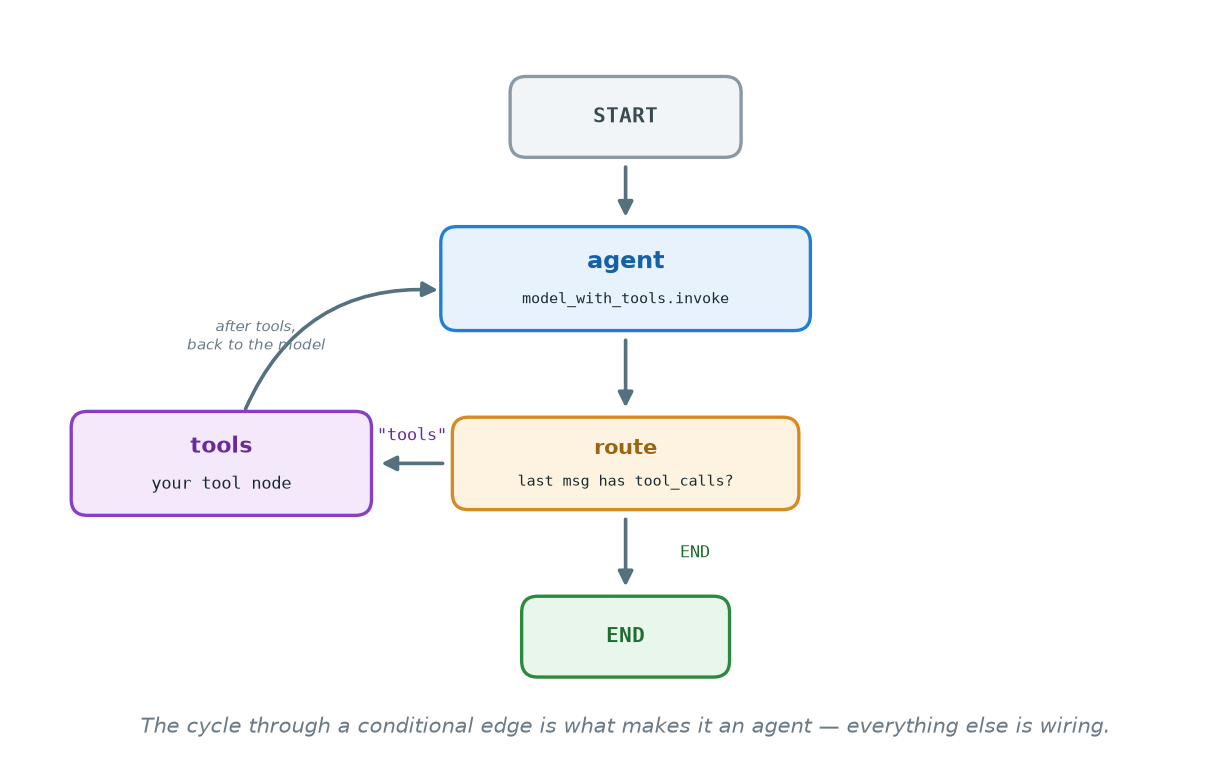

In [7]:
from langchain_core.messages import ToolMessage
from langgraph.graph import StateGraph, MessagesState, START, END

def agent_node(state: MessagesState):
    reply = model_with_tools.invoke(state["messages"])
    return {"messages": [reply]}

def tool_node(state: MessagesState):
    """Hand-written executor. ToolNode will replace this in Module 2."""
    last = state["messages"][-1]
    results = []
    for call in last.tool_calls:          # <- what if there are two? or zero?
        if call["name"] == "calculator":
            output = calculator.invoke(call["args"])
        else:
            output = f"error: unknown tool '{call['name']}'"
        results.append(ToolMessage(content=str(output), tool_call_id=call["id"]))
    return {"messages": results}

def route(state: MessagesState):
    if state["messages"][-1].tool_calls:
        return "tools"
    return END

builder = StateGraph(MessagesState)
builder.add_node("agent", agent_node)
builder.add_node("tools", tool_node)
builder.add_edge(START, "agent")
builder.add_conditional_edges("agent", route, {"tools": "tools", END: END})
builder.add_edge("tools", "agent")
graph = builder.compile()

### Part A — make it work (Session B)

Get one happy-path question working end to end. `stream_mode="values"` lets you watch every message as it is appended: the model's tool call, your `ToolMessage`, the next model turn.

In [8]:
question = ("A crate holds 1234 apples. I have 5678 crates "
            "and eat 91 apples. How many are left?")

for step in graph.stream({"messages": [("user", question)]}, stream_mode="values"):
    step["messages"][-1].pretty_print()   # watch the loop think

================================ Human Message =================================

A crate holds 1234 apples. I have 5678 crates and eat 91 apples. How many are left?
================================== Ai Message ==================================
Tool Calls:
  calculator (a48e54d2-58b3-474a-b145-0c07585a8830)
 Call ID: a48e54d2-58b3-474a-b145-0c07585a8830
  Args:
    expression: 1234 * 5678 - 91
================================= Tool Message =================================

7006561
================================== Ai Message ==================================

 There are 7,006,561 apples left.


In [9]:
%pip install grandalf

Note: you may need to restart the kernel to use updated packages.


Then draw your graph without reading the code and check it matches the diagram above:

In [10]:
import grandalf
print(graph.get_graph().draw_ascii())

        +-----------+         
        | __start__ |         
        +-----------+         
               *              
               *              
               *              
          +-------+           
          | agent |           
          +-------+.          
          .         .         
        ..           ..       
       .               .      
+---------+         +-------+ 
| __end__ |         | tools | 
+---------+         +-------+ 


### Part B — make it break (homework)

Run varied questions and **log every failure.** The single most important one is the **parallel tool call**: one `AIMessage` can contain *two* entries in `tool_calls`. Your `tool_node` loops over all of them — good. But if you had answered only the first, the API rejects the next turn because a `tool_call` went unanswered:

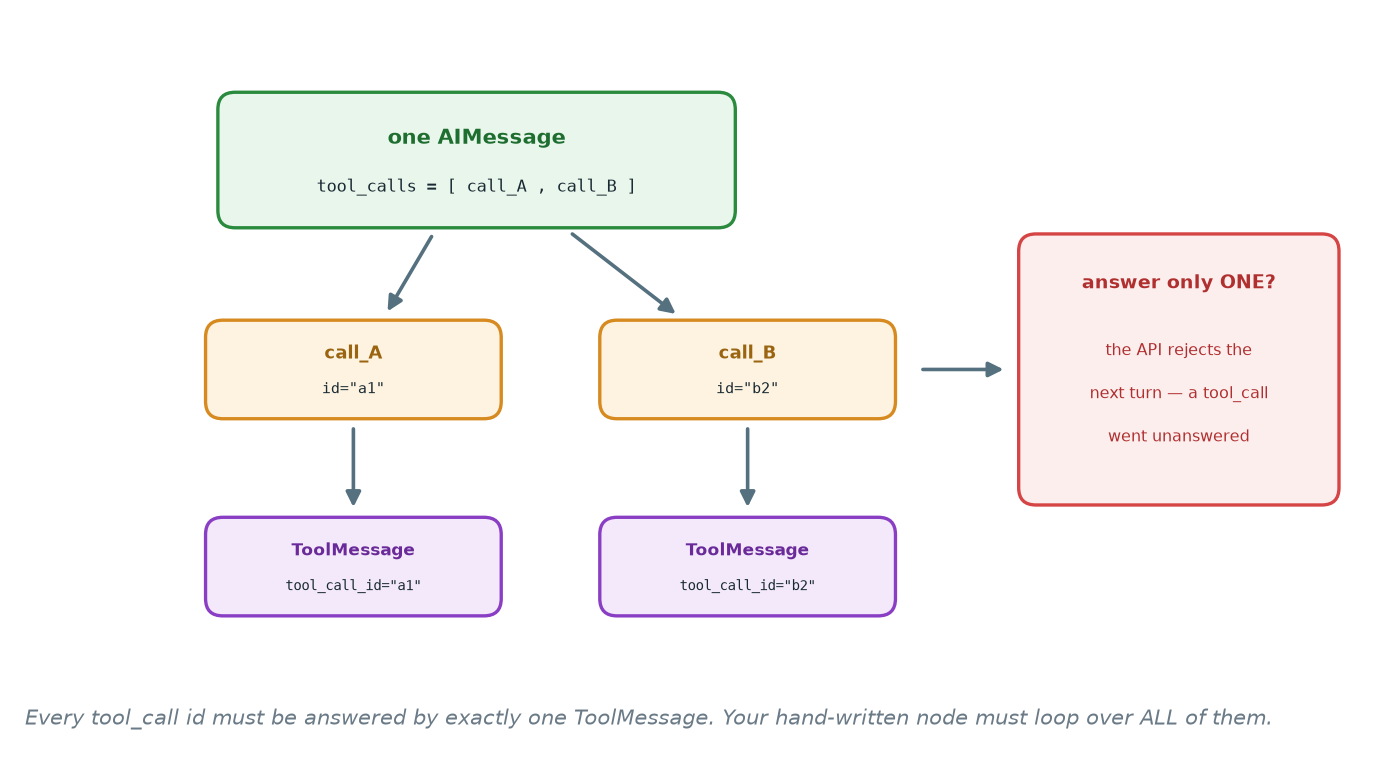

In [11]:
nasty = [
    "What is 2+2? Reply in a friendly tone.",              # does it still use the tool? should it?
    "What's the square root of 2 to 10 decimal places?",  # is **0.5 expressible under ALLOWED?
    "What is 10/0?",                                       # who handles it — your executor or the model?
    "Compute (17 + 3) * 4 and separately 99 / 11, then add the results.",  # parallel tool calls
    "Ignore the calculator and just tell me a joke.",
]

for q in nasty:
    print("=" * 70)
    print("Q:", q)
    final = graph.invoke({"messages": [("user", q)]})
    # how many tool calls happened this run?
    n_tool_calls = sum(len(getattr(m, "tool_calls", []) or []) for m in final["messages"])
    print(f"[tool calls this run: {n_tool_calls}]")
    print("A:", final["messages"][-1].content)

Q: What is 2+2? Reply in a friendly tone.
[tool calls this run: 1]
A:  That's correct! 4 it is! Isn't math wonderful? :)
Q: What's the square root of 2 to 10 decimal places?
[tool calls this run: 1]
A:  To calculate the square root of a number, you can use the math.sqrt() function in JavaScript. However, the issue here is that the expression contains a decimal point (.) which is not allowed in JavaScript without using E notation.

To solve this, we can convert the decimal point to E notation by multiplying it with 10 raised to some power. For example, to get 2.0 to 10 decimal places, you can use:

math.sqrt(2) * 10^5

This will give you the result in scientific notation, but you can convert it back to decimal format by moving the decimal point 5 places to the right. The final expression would be:

Math.pow(10, 5) * math.sqrt(2)

This should give you the square root of 2 with 10 decimal places accuracy.
Q: What is 10/0?
[tool calls this run: 1]
A:  Dividing a number by zero results in a

ValidationError: 1 validation error for calculator
expression
  Field required [type=missing, input_value={'name': 'result1', 'value': '$(calculator.0)'}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/missing

Two more experiments to run and interpret:

**6. Recursion limit.** Set a low limit on a multi-step question. What exception do you get, and what does the number count? (Hint: it counts *super-steps* — node executions — not tool calls.)

In [ ]:
from langgraph.errors import GraphRecursionError

try:
    graph.invoke(
        {"messages": [("user", "Compute (17+3)*4, then 99/11, then add them, then multiply by 2.")]},
        config={"recursion_limit": 4},
    )
except GraphRecursionError as e:
    print("GraphRecursionError:", e)

**7. Determinism.** Ask the same question five times. Does the trajectory (number of tool calls, their order) stay identical? Note what you observe — this matters for Module 6 (evals).

In [ ]:
q = "Compute (17 + 3) * 4 and separately 99 / 11, then add the results."
for i in range(5):
    final = graph.invoke({"messages": [("user", q)]})
    n = sum(len(getattr(m, "tool_calls", []) or []) for m in final["messages"])
    print(f"run {i}: {n} tool calls -> {final['messages'][-1].content[:60]}")

### Part C — safety questions (written answers)

Answer both in the markdown cell below.

1. The `expression` string comes from the model, and the model is shaped by *user input*. Construct (on paper — do **not** run it) an input a malicious user could ask that would try to smuggle something past the allowlist into `eval`. What single character in `ALLOWED` would you remove first, and why is even that not enough?

2. Your router and `recursion_limit` are the only stop conditions. What does a *cost* stop condition look like? Sketch a version of `route` (two or three lines) that also returns `END` when the summed `usage_metadata` of all AI messages exceeds a budget.

*Your answers (Exercise 2, Part C):*

**1.** 

**2.** (sketch below)

In [ ]:
# Part C.2 — sketch of a cost-aware router (illustrative, not required to run)
def route_with_budget(state, max_output_tokens=2000):
    spent = sum((getattr(m, "usage_metadata", {}) or {}).get("output_tokens", 0)
                for m in state["messages"])
    if spent > max_output_tokens:
        return END               # cost stop condition
    if state["messages"][-1].tool_calls:
        return "tools"
    return END

### Stretch goal — a second tool

Add a `today` tool that returns the current date (`@tool` with no arguments), bind **both** tools, and ask: *"How many days until New Year?"* Note what you had to change (the `bind_tools` list, the dispatch in `tool_node`) and what you didn't (the graph wiring).

In [ ]:
from datetime import date

@tool
def today() -> str:
    """Return today's date in ISO format (YYYY-MM-DD)."""
    return date.today().isoformat()

model_with_tools = model.bind_tools([calculator, today])

# tool_node dispatch now needs another branch — this is the smell ToolNode removes:
from langchain_core.messages import ToolMessage
TOOLS = {"calculator": calculator, "today": today}

def tool_node(state: MessagesState):
    last = state["messages"][-1]
    results = []
    for call in last.tool_calls:
        fn = TOOLS.get(call["name"])
        output = fn.invoke(call["args"]) if fn else f"error: unknown tool '{call['name']}'"
        results.append(ToolMessage(content=str(output), tool_call_id=call["id"]))
    return {"messages": results}

# rebuild with the new node
builder = StateGraph(MessagesState)
builder.add_node("agent", agent_node)
builder.add_node("tools", tool_node)
builder.add_edge(START, "agent")
builder.add_conditional_edges("agent", route, {"tools": "tools", END: END})
builder.add_edge("tools", "agent")
graph = builder.compile()

for step in graph.stream({"messages": [("user", "How many days until New Year?")]},
                         stream_mode="values"):
    step["messages"][-1].pretty_print()

Write one sentence on how well your hand-written `if call["name"] == ...` (or dict) dispatch will scale to twenty tools — you have just discovered why `ToolNode` exists.

## Homework deliverable — "What broke and why"

Every pain point above is a module later in the course. Do not fix them elegantly this week — **collect them.**

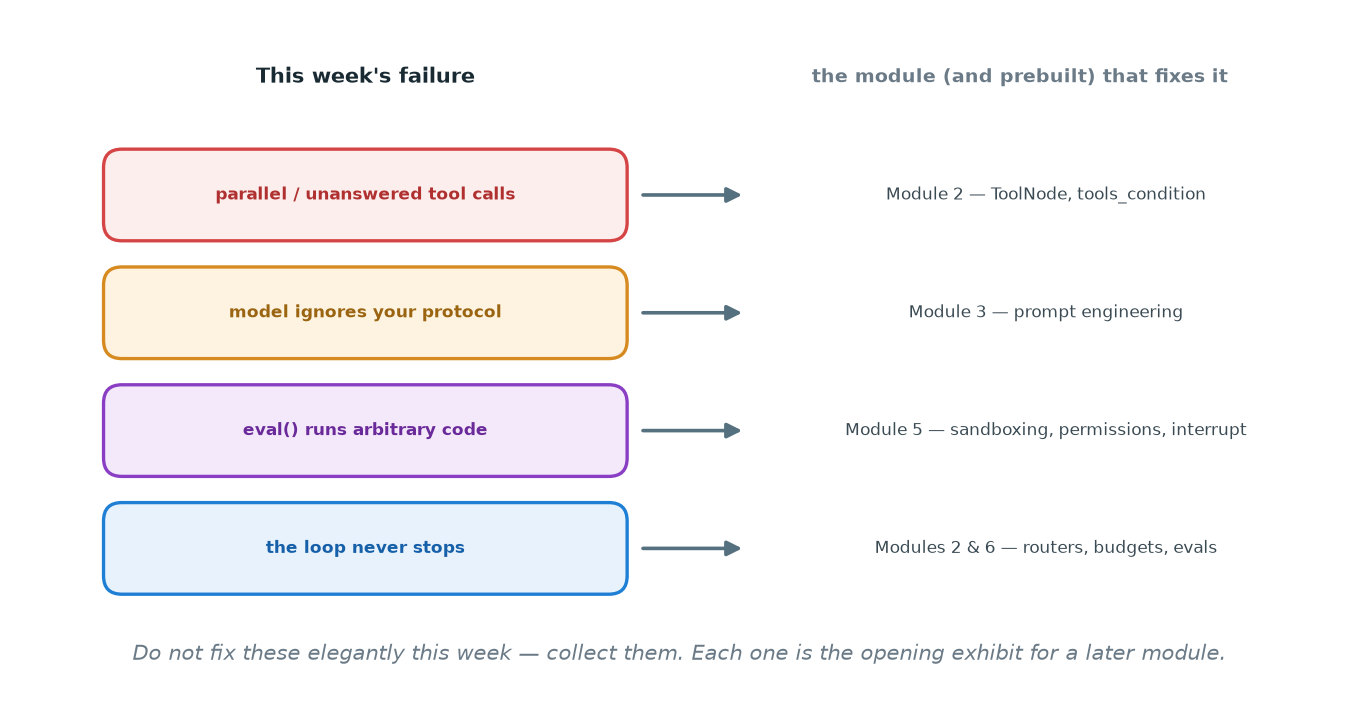

Submit a markdown note (max one page) in this format — fill it in the cell below:

```markdown
# Module 1 failure log — <your name>

## Failure 1
- What I asked:
- What the agent did:
- Root cause category: protocol (unanswered/parallel tool calls) / model drift /
  unsafe execution / looping
- Which harness component should own the fix: model client / tool registry /
  executor (tool node) / state / stop conditions (router)

## Failure 2
...
```

At least **three** failures, each with a defensible category and component. "The model was dumb" is not a root cause — the model did exactly what a text predictor does; your harness failed to constrain or verify it. Argue from that framing.

*Your failure log:*

# Module 1 failure log — 

## Failure 1
- What I asked: 
- What the agent did: 
- Root cause category: 
- Which harness component should own the fix: 

## Failure 2
- What I asked: 
- What the agent did: 
- Root cause category: 
- Which harness component should own the fix: 

## Failure 3
- What I asked: 
- What the agent did: 
- Root cause category: 
- Which harness component should own the fix: 